In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
plt.style.use('ggplot')

In [3]:
# Chaque fichier a un encodage différent, on le précise
df_s1 = pd.read_csv('data/2024_S1_NB_FER.txt', sep='\t', encoding='iso-8859-1', dtype=str)
df_t3 = pd.read_csv('data/2024_T3_NB_FER.txt', sep='\t', encoding='utf-8', dtype=str)
df_t4 = pd.read_csv('data/2024_T4_NB_FER.txt', sep='\t', encoding='utf-8', dtype=str)

print(f"S1 : {len(df_s1)} lignes")
print(f"T3 : {len(df_t3)} lignes")
print(f"T4 : {len(df_t4)} lignes")

S1 : 859043 lignes
T3 : 466121 lignes
T4 : 472132 lignes


In [4]:
df = pd.concat([df_s1, df_t3, df_t4], ignore_index=True)
print(f"Total : {len(df)} lignes")

Total : 1797296 lignes


In [5]:
# S1 = '01/01/2024', T3 = '01/07/24', T4 = '2024-10-01'
df['JOUR'] = pd.to_datetime(df['JOUR'], format='mixed', dayfirst=True, errors='coerce')

In [6]:
#  NB_VALD : enlever les espaces ('2 093' -> 2093) puis convertir en int ---
df['NB_VALD'] = df['NB_VALD'].str.replace(' ', '').str.replace('\xa0', '')
df['NB_VALD'] = pd.to_numeric(df['NB_VALD'], errors='coerce')

In [7]:
#  Suppression des lignes avec des valeurs invalides ---
df = df.dropna(subset=['JOUR', 'NB_VALD'])
df['NB_VALD'] = df['NB_VALD'].astype(int)


In [8]:
# Ajout de variables temporelles utiles ---
df['mois'] = df['JOUR'].dt.month
df['jour_semaine'] = df['JOUR'].dt.day_name()
df['weekend'] = df['JOUR'].dt.dayofweek >= 5

In [9]:
df.to_csv('validations_fer_2024.csv', index=False)
print(f"\n✅ Fichier propre sauvegardé : {len(df)} lignes")


✅ Fichier propre sauvegardé : 1797296 lignes


In [10]:
# 3. EXPLORATION


print("\n--- APERÇU ---")
print(df.head())

print("\n--- INFOS ---")
print(df.info())

print(f"\nPériode : {df['JOUR'].min().date()} -> {df['JOUR'].max().date()}")
print(f"Arrêts uniques : {df['CODE_STIF_ARRET'].nunique()}")
print(f"Total validations : {df['NB_VALD'].sum():,}")


--- APERÇU ---
        JOUR CODE_STIF_TRNS CODE_STIF_RES CODE_STIF_ARRET  LIBELLE_ARRET  \
0 2024-01-01            100           110               1  PORTE MAILLOT   
1 2024-01-01            100           110               1  PORTE MAILLOT   
2 2024-01-01            100           110               1  PORTE MAILLOT   
3 2024-01-01            100           110               1  PORTE MAILLOT   
4 2024-01-01            100           110               1  PORTE MAILLOT   

  ID_ZDC               CATEGORIE_TITRE  NB_VALD  mois jour_semaine  weekend  
0  71379                     Amethyste       78     1       Monday    False  
1  71379                 Autres titres      885     1       Monday    False  
2  71379  Contrat Solidarité Transport      371     1       Monday    False  
3  71379                Forfait Navigo     1551     1       Monday    False  
4  71379               Forfaits courts      107     1       Monday    False  

--- INFOS ---
<class 'pandas.core.frame.DataFrame'>
RangeI


--- TOP 10 DES ARRÊTS ---
LIBELLE_ARRET
SAINT-LAZARE     69975354
CHATELET         45018002
GARE DE LYON     39044253
LA DEFENSE       33612874
MONTPARNASSE     31338213
GARE DU NORD     30784793
GARE DE L'EST    26920265
LES HALLES       14852734
REPUBLIQUE       14420562
NATION           12190711
Name: NB_VALD, dtype: int64


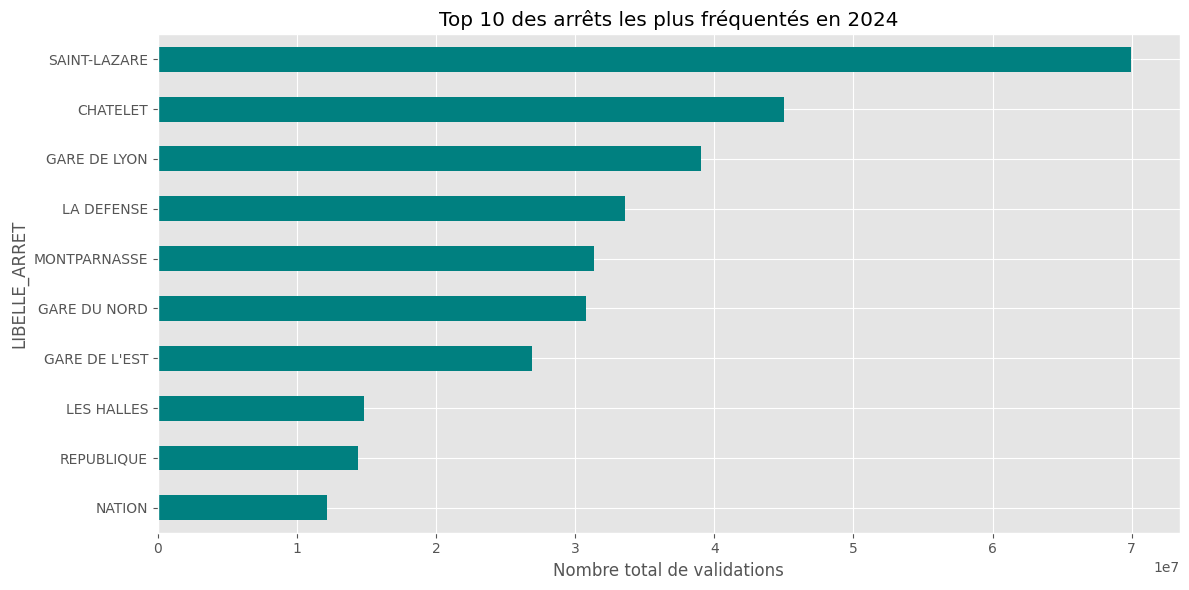

In [11]:
# --- Top 10 des arrêts les plus fréquentés ---
print("\n--- TOP 10 DES ARRÊTS ---")
top_arrets = df.groupby('LIBELLE_ARRET')['NB_VALD'].sum().sort_values(ascending=False).head(10)
print(top_arrets)

plt.figure(figsize=(12, 6))
top_arrets.plot(kind='barh', color='teal')
plt.title('Top 10 des arrêts les plus fréquentés en 2024')
plt.xlabel('Nombre total de validations')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



--- VALIDATIONS PAR MOIS ---
mois
1     157689630
2     150469359
3     168131510
4     154432336
5     155355343
6     162215770
7     150652787
8     117633106
9     169874517
10    182739985
11    172779212
12    164025275
Name: NB_VALD, dtype: int64


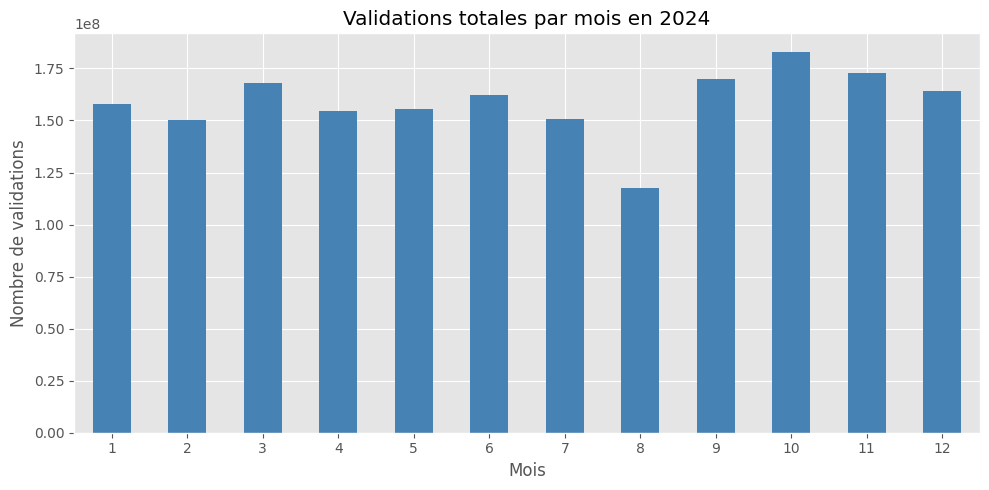

In [12]:
# --- Évolution mensuelle ---
print("\n--- VALIDATIONS PAR MOIS ---")
par_mois = df.groupby('mois')['NB_VALD'].sum()
print(par_mois)

plt.figure(figsize=(10, 5))
par_mois.plot(kind='bar', color='steelblue')
plt.title('Validations totales par mois en 2024')
plt.xlabel('Mois')
plt.ylabel('Nombre de validations')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


--- VALIDATIONS PAR CATÉGORIE ---
CATEGORIE_TITRE
Forfait Navigo                  1015278420
Imagine R                        365475922
Contrat Solidarité Transport     246079227
Autres titres                    170146654
NON DEFINI                        50647531
Amethyste                         41757750
Forfaits courts                   16613326
Name: NB_VALD, dtype: int64


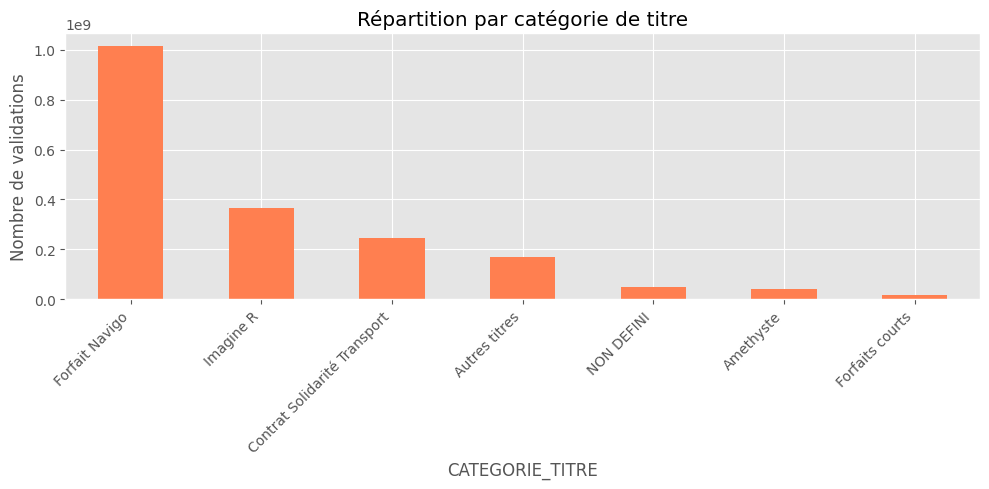

In [13]:
# --- Répartition par catégorie de titre ---
print("\n--- VALIDATIONS PAR CATÉGORIE ---")
par_cat = df.groupby('CATEGORIE_TITRE')['NB_VALD'].sum().sort_values(ascending=False)
print(par_cat)

plt.figure(figsize=(10, 5))
par_cat.plot(kind='bar', color='coral')
plt.title('Répartition par catégorie de titre')
plt.ylabel('Nombre de validations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


--- SEMAINE vs WEEK-END ---
jour_semaine
Monday       291476530
Tuesday      321938160
Wednesday    306132867
Thursday     316867534
Friday       301691255
Saturday     217102938
Sunday       150789546
Name: NB_VALD, dtype: int64


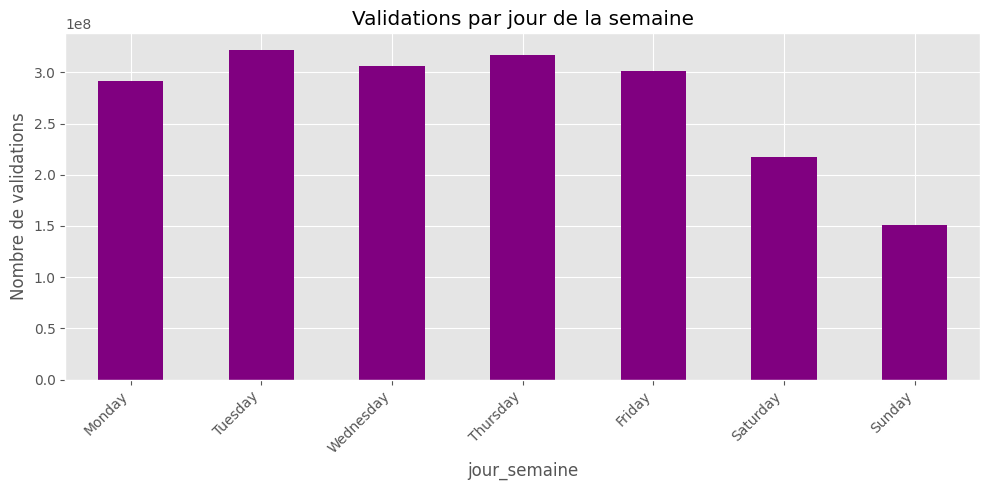

In [16]:
# --- Comparaison semaine vs week-end ---
print("\n--- SEMAINE vs WEEK-END ---")
par_jour = df.groupby('jour_semaine')['NB_VALD'].sum()
# Ordre des jours
ordre = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
par_jour = par_jour.reindex(ordre)
print(par_jour)

plt.figure(figsize=(10, 5))
par_jour.plot(kind='bar', color='purple')
plt.title('Validations par jour de la semaine')
plt.ylabel('Nombre de validations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()